In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
Cancer_data = pd.read_csv('C:\Data Analyst Training\Machine_learning_Project\Wather_Prediction\Machine_Learning_Project\Predict-Cancer-Malignant-or-Benign\Data\data-cancer.csv')
Cancer_data

,id,diagnosis,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
Cancer_data.isnull().sum()

id                         0
diagnosis                  0
Radius_mean                0
Texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [8]:
Cancer_data.shape


(569, 32)

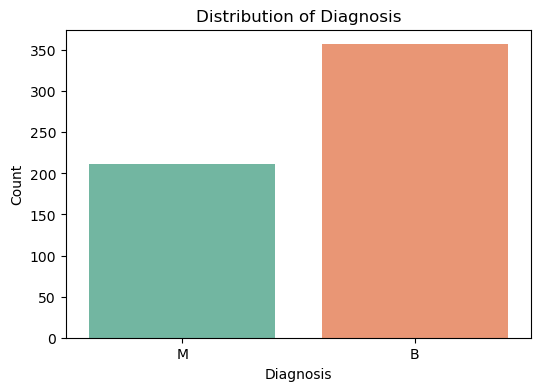

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', hue='diagnosis', data=data, palette='Set2', legend=False)
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()



In [14]:
A = Cancer_data['diagnosis'].value_counts()
plt.figure(figsize=(6,4))
ax = sns.countplot(x='diagnosis', hue='diagnosis', data=data, palette='Set2', legend=False)
plt.title("Distribution of Diagnosis")
plt.xlabel("Count")

total = A.sum()
for i, v in enumerate(A.values):
    ax.text(v + 1, i, f"{v} ({v/total:.1%})", va='center')
plt.show()

In [19]:
Cancer_data['diagnosis']=data['diagnosis'].map({'M':1,'B':0})
Cancer_data.head()

,id,diagnosis,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [20]:
del Cancer_data['id']
Cancer_data.head()

,diagnosis,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
indepedent_x = Cancer_data.loc[:,Cancer_data.columns[1:]]
dependent_y = Cancer_data['diagnosis']

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

independent_train, independent_test, dependent_train, dependent_test = train_test_split(indepedent_x, dependent_y, test_size=0.2)


dt = DecisionTreeClassifier()
dt.fit(independent_train, dependent_train) 
cancer_pred = dt.predict(independent_test)
cancer_pred

array([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0])

In [36]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(independent_train, dependent_train)
dt_pred = dt.predict(independent_test)
dt_acc = accuracy_score(dependent_test, dt_pred)
print("Decision Tree Test Accuracy:", dt_acc)

Decision Tree Test Accuracy: 0.9210526315789473


In [33]:
y_pred = dt.predict(independent_test) 
acc = accuracy_score(dependent_test, cancer_pred)

In [34]:
for smoothing in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    nb = GaussianNB(var_smoothing=smoothing)
    nb.fit(independent_train, dependent_train)
    trainAccuracy = accuracy_score(dependent_train, nb.predict(independent_train))
    
    nb = GaussianNB(var_smoothing=smoothing)
    valAccuracy = cross_val_score(nb, independent_train, dependent_train, cv=10)
    
    print("Var Smoothing : ", smoothing, " Training Accuracy : ", trainAccuracy, " Cross val score : ", np.mean(valAccuracy))

Var Smoothing :  1e-09  Training Accuracy :  0.9406593406593406  Cross val score :  0.936183574879227
Var Smoothing :  1e-08  Training Accuracy :  0.9340659340659341  Cross val score :  0.9341062801932368
Var Smoothing :  1e-07  Training Accuracy :  0.9318681318681319  Cross val score :  0.9320289855072463
Var Smoothing :  1e-06  Training Accuracy :  0.9230769230769231  Cross val score :  0.9232850241545894
Var Smoothing :  1e-05  Training Accuracy :  0.9252747252747253  Cross val score :  0.9232850241545894
Var Smoothing :  0.0001  Training Accuracy :  0.9208791208791208  Cross val score :  0.921111111111111
Var Smoothing :  0.001  Training Accuracy :  0.9098901098901099  Cross val score :  0.9079227053140096
Var Smoothing :  0.01  Training Accuracy :  0.9076923076923077  Cross val score :  0.9078743961352658
Var Smoothing :  0.1  Training Accuracy :  0.8967032967032967  Cross val score :  0.8969082125603866


In [37]:
nb_final = GaussianNB(var_smoothing=1e-9)
nb_final.fit(independent_train, dependent_train)
nb_pred = nb_final.predict(independent_test)
nb_acc = accuracy_score(dependent_test, nb_pred)
print("Naive Bayes Test Accuracy:", nb_acc)

Naive Bayes Test Accuracy: 0.8859649122807017


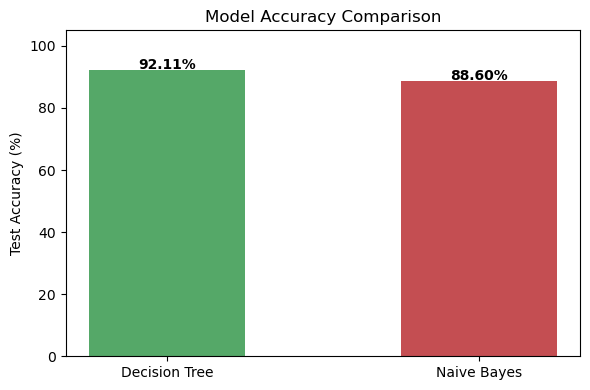

In [38]:
fig, ax = plt.subplots(figsize=(6,4))
models = ['Decision Tree', 'Naive Bayes']
accs = [dt_acc*100, nb_acc*100]
bars = ax.bar(models, accs, color=['#55A868', '#C44E52'], width=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

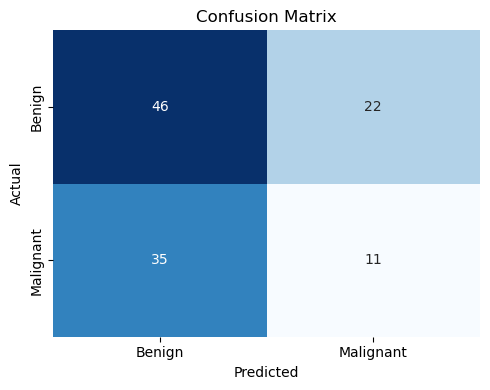

              precision    recall  f1-score   support

      Benign       0.57      0.68      0.62        68
   Malignant       0.33      0.24      0.28        46

    accuracy                           0.50       114
   macro avg       0.45      0.46      0.45       114
weighted avg       0.47      0.50      0.48       114



In [41]:
best_pred = nb_pred if nb_acc >= dt_acc else dt_pred
cm = confusion_matrix(dependent_test, best_pred)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(dependent_test, best_pred, target_names=['Benign','Malignant']))

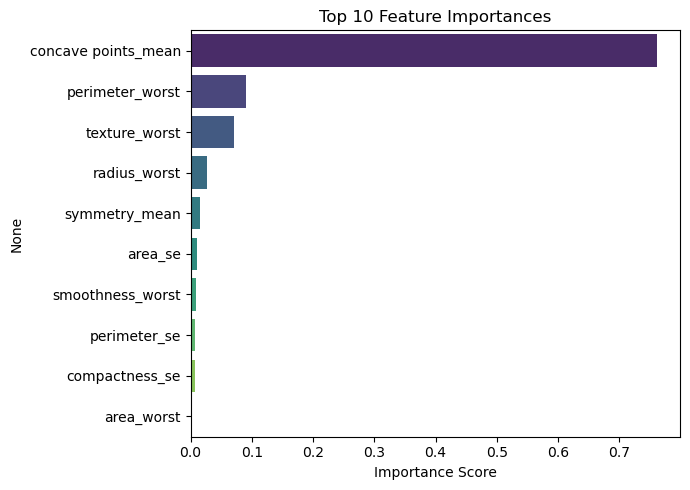

In [43]:
importances = pd.Series(dt.feature_importances_, index=indepedent_x.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()